Columns in dataset: Index(['Unnamed: 0', 'Player_Id', 'Runs', 'Balls_played', 'Strike_Rate',
       'cluster', 'Player_Name', 'Batting_Hand', 'DOB', 'Country'],
      dtype='object')


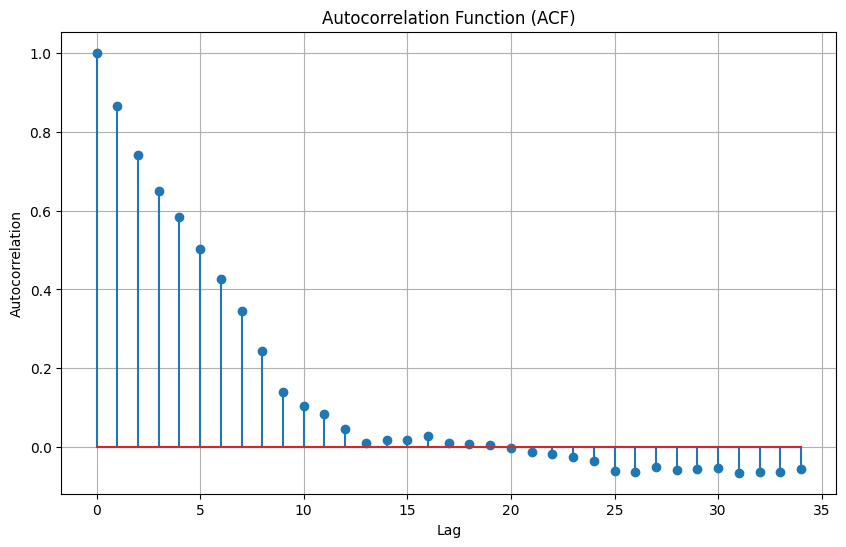

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/COLAB PROJECTS/Time Series/Batsmen.csv')

# Display columns (to help you confirm column name)
print("Columns in dataset:", df.columns)

data = df['Runs'].dropna().values

# Parameters
N = len(data)
lags = range(35)

autocorr_values = []

# Mean and Variance
mean_data = np.mean(data)
variance_data = np.var(data)

# ACF Calculation
for lag in lags:
    if lag == 0:
        autocorr_values.append(1)
    else:
        auto_cov = np.sum((data[:-lag] - mean_data) * (data[lag:] - mean_data)) / N
        autocorr_values.append(auto_cov / variance_data)

# Plot ACF
plt.figure(figsize=(10, 6))
plt.stem(lags, autocorr_values)

plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.grid(True)
plt.show()